In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

from utils import *

In [2]:
%matplotlib inline
auto_plot_style()

In [3]:
path      = Path("/home/gonzalo/data/COLINA/mc/colina/pitch_2mm_diam_10um/")
filenames = sorted(path.glob("*.h5"))
filename  = filenames[0]
len(filenames)

10

In [4]:
testdf = imgs_from_file(filename)
testdf

,x0,y0,z0,r0,image
event,,,,,
0,-13.329388,23.670586,-5.193165,27.165589,"[[[0, 0, 0, 0, 0, 2, 7, 5, 10, 1], [0, 0, 2, 0..."
1,-0.767696,-31.655275,-5.196241,31.664582,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0,..."
2,-20.035257,11.330605,-5.188180,23.017258,"[[[0, 1, 0, 0, 5, 14, 9, 16, 6, 3], [0, 0, 1, ..."
3,-8.701822,-9.360389,-5.183915,12.780399,"[[[0, 0, 3, 1, 0, 0, 0, 0, 0, 0], [1, 3, 6, 6,..."
4,14.039152,-20.715634,-5.174241,25.024694,"[[[0, 0, 0, 1, 1, 0, 1, 0, 0, 0], [1, 0, 0, 0,..."
...,...,...,...,...,...
49995,14.771619,17.851778,-5.195735,23.170816,"[[[0, 0, 0, 0, 0, 2, 0, 0, 1, 0], [0, 0, 0, 1,..."
49996,-15.533717,-25.187415,-5.174829,29.592266,"[[[1, 5, 11, 6, 0, 1, 0, 0, 0, 0], [2, 6, 12, ..."
49997,0.962964,12.125243,-5.195847,12.163422,"[[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 2, 1,..."


In [5]:
config    = simconfig(filename)
sipm_pos  = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[0]
sipm_x    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[1]
sipm_y    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[2]
extents   = sipm_extent   (config.sipm_size, config.sipm_gap, config.n_sipm_side)
ticks     = np.arange(-15, 16, 10) if config.el_diam==32 else np.arange(-30, 31, 15)

rmax   = config.el_diam/2
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
drbins = np.linspace(    0, rmax, 81)

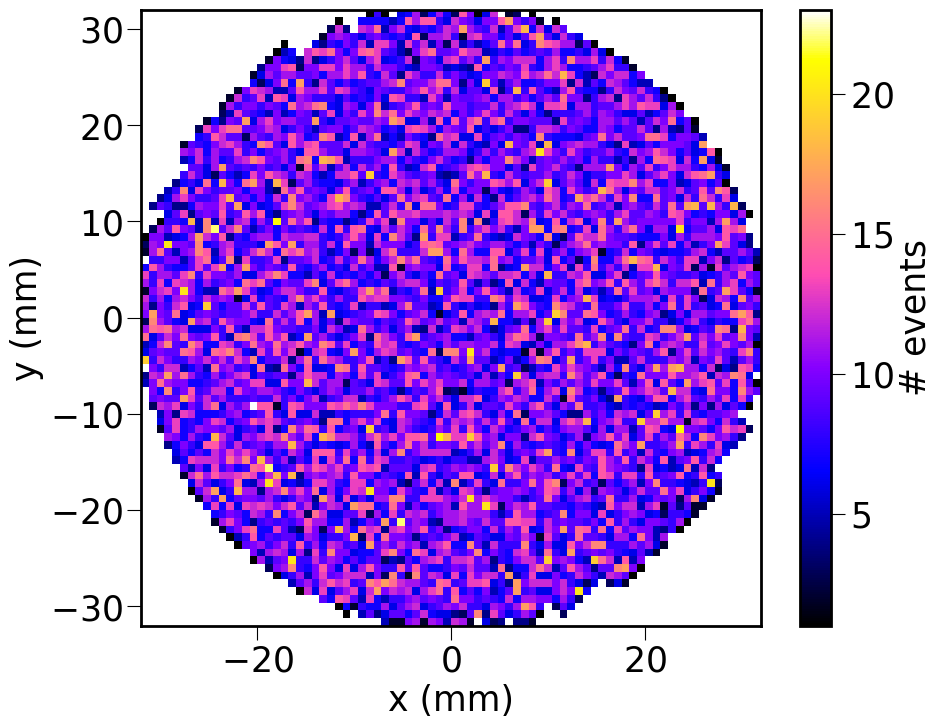

In [6]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

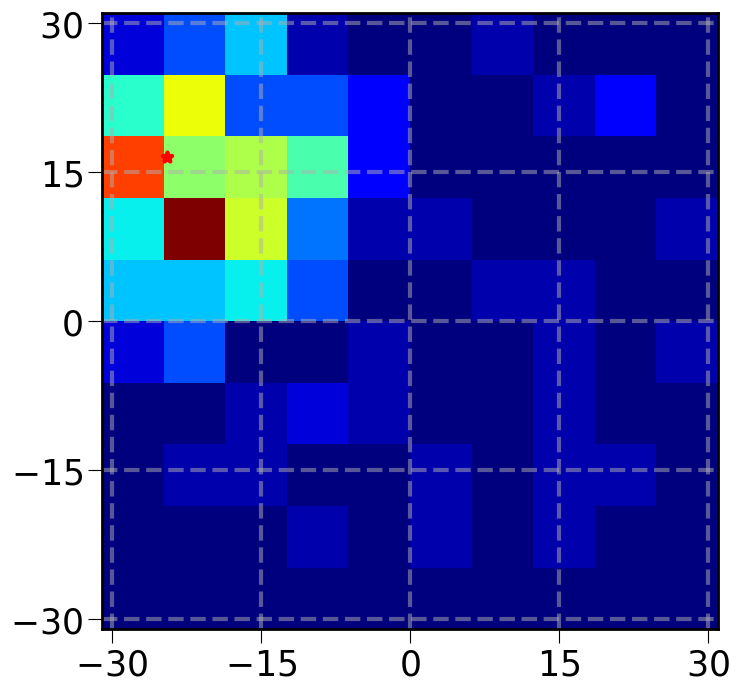

In [7]:
row = testdf.iloc[15]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extents, cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.xticks(ticks)
plt.yticks(ticks)
plt.grid()

# Barycenter

In [8]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [9]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,-11.113605,17.672109,-13.329388,23.670586,-5.193165,27.165589,2.215783,-5.998477,6.394640
1,-0.459259,-20.121296,-0.767696,-31.655275,-5.196241,31.664582,0.308437,11.533978,11.538102
2,-16.130814,9.642442,-20.035257,11.330605,-5.188180,23.017258,3.904443,-1.688164,4.253772
3,-5.805780,-9.963006,-8.701822,-9.360389,-5.183915,12.780399,2.896042,-0.602617,2.958075
4,13.391156,-17.187075,14.039152,-20.715634,-5.174241,25.024694,-0.647995,3.528559,3.587566
...,...,...,...,...,...,...,...,...,...
49995,11.985561,15.881283,14.771619,17.851778,-5.195735,23.170816,-2.786057,-1.970495,3.412472
49996,-11.028846,-15.887500,-15.533717,-25.187415,-5.174829,29.592266,4.504870,9.299915,10.333551
49997,0.809763,9.692612,0.962964,12.125243,-5.195847,12.163422,-0.153201,-2.432631,2.437451


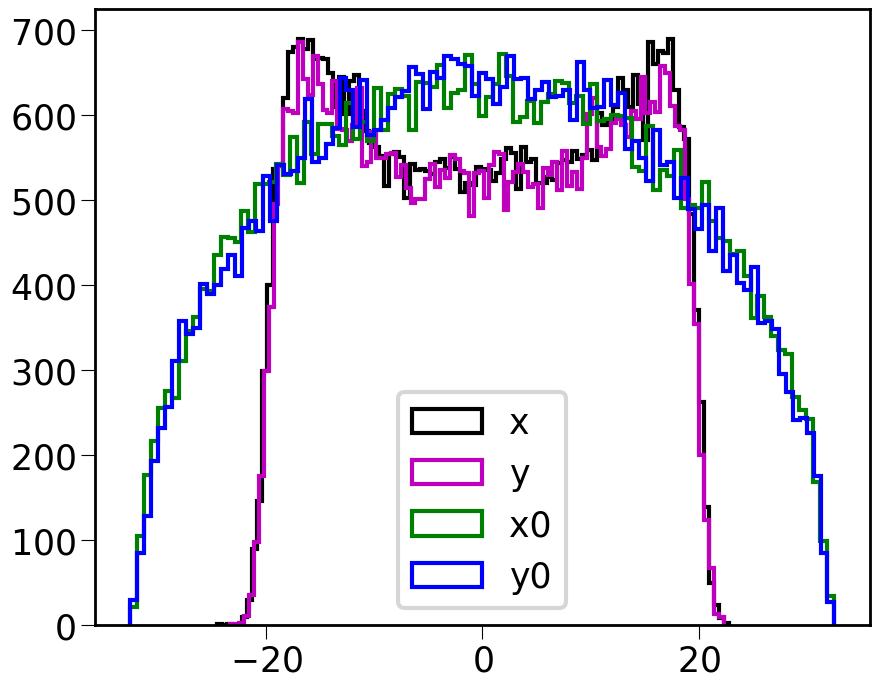

In [10]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

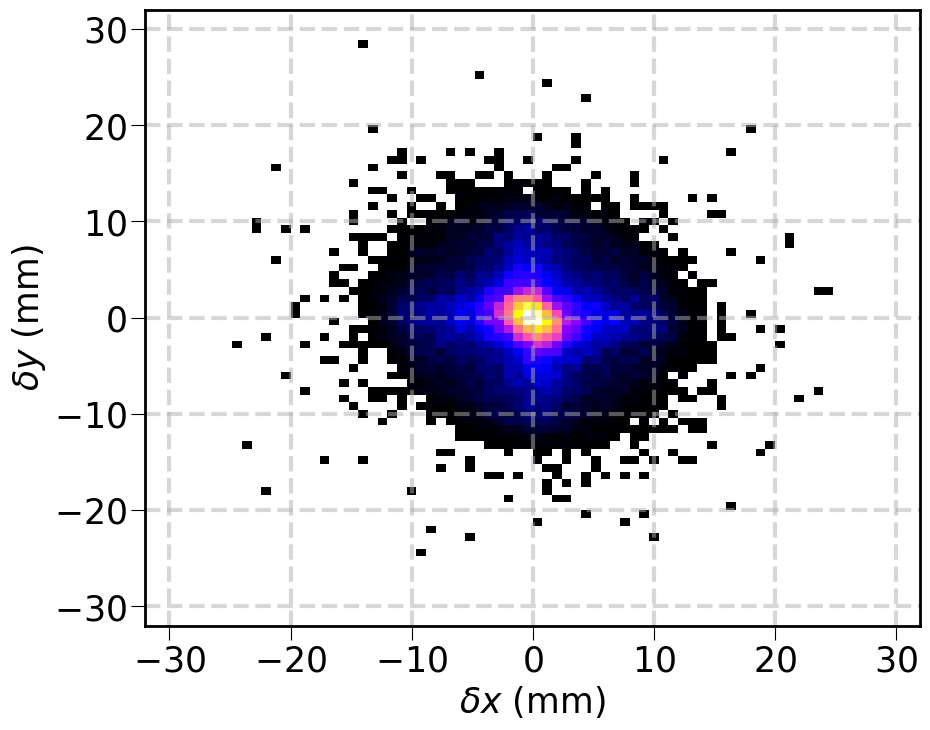

In [11]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

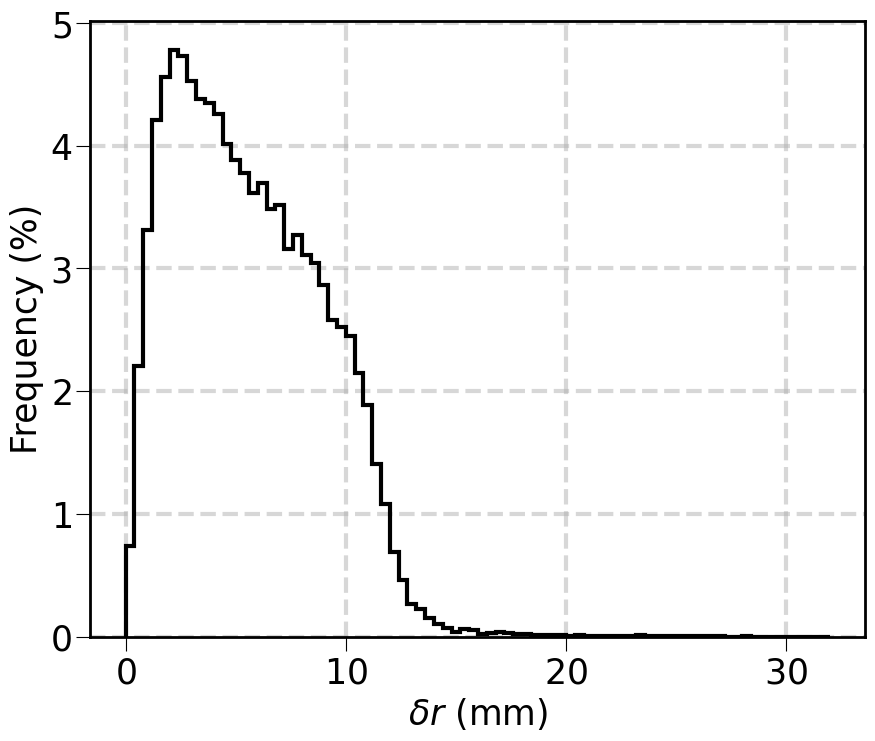

In [12]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

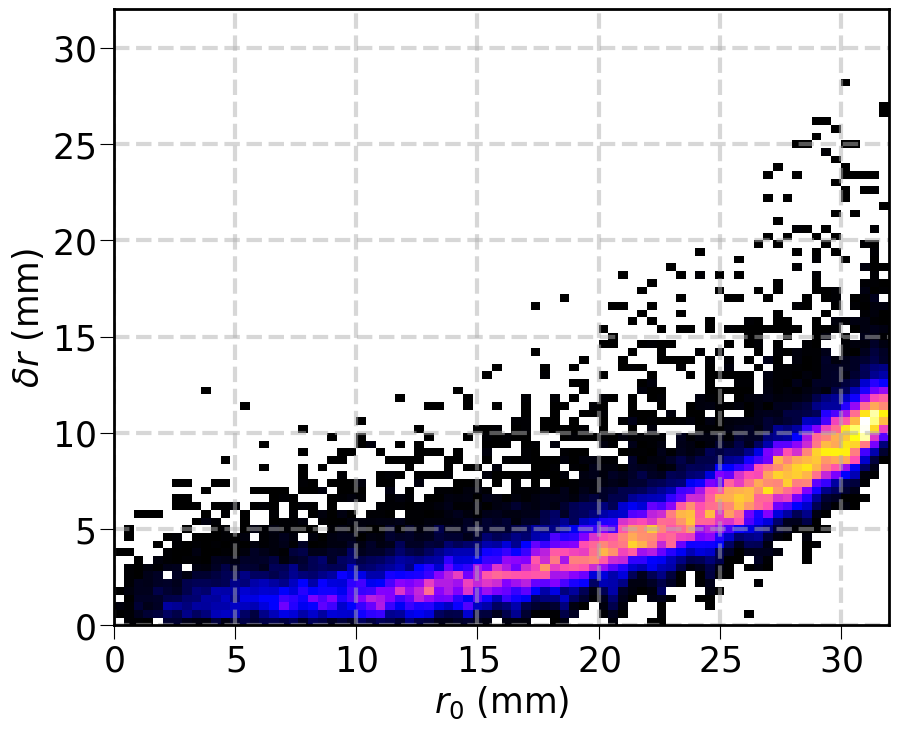

In [13]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

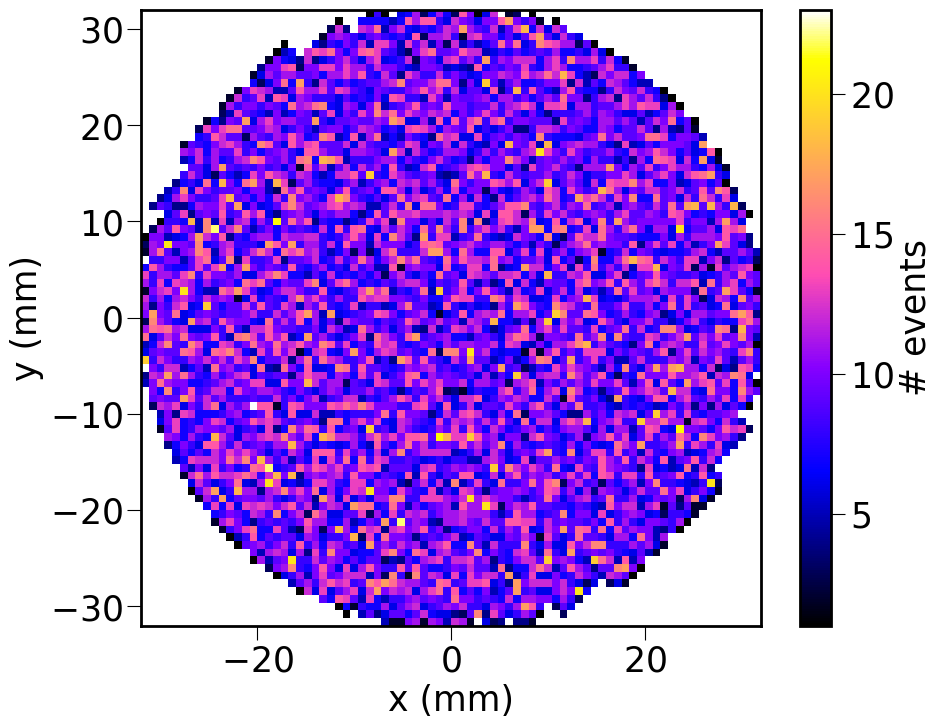

In [14]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

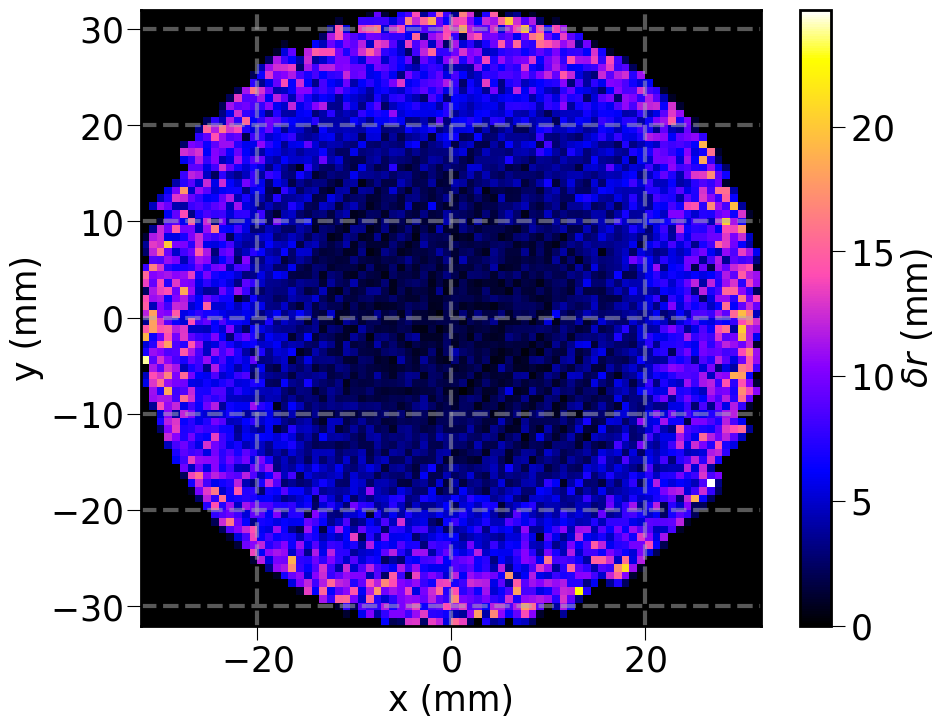

In [15]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

# NN

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

In [17]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [18]:
nfiles    = len(filenames)
train     = pd.concat([imgs_from_file(filename) for filename in filenames[:nfiles//2 ]])
test      = pd.concat([imgs_from_file(filename) for filename in filenames[ nfiles//2:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [19]:
model     = Linear(config.n_sipm_side, config.n_sipm_side)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
epochs = 100
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 100 of 100 | 10.83 s/item | ETA 0.2 min | Ellapsed 17.9 min


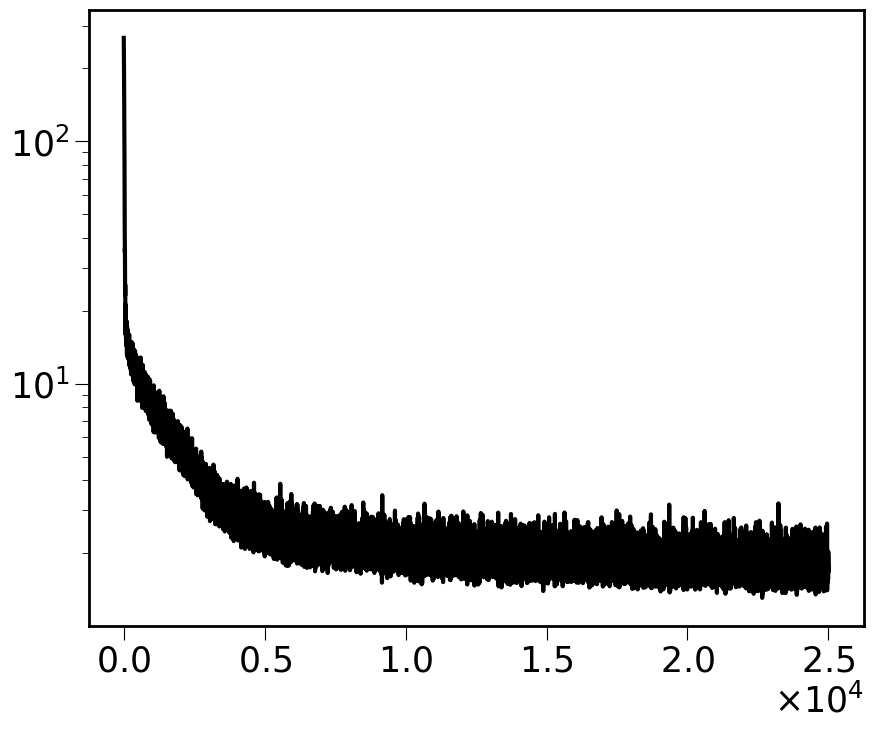

In [21]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [22]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

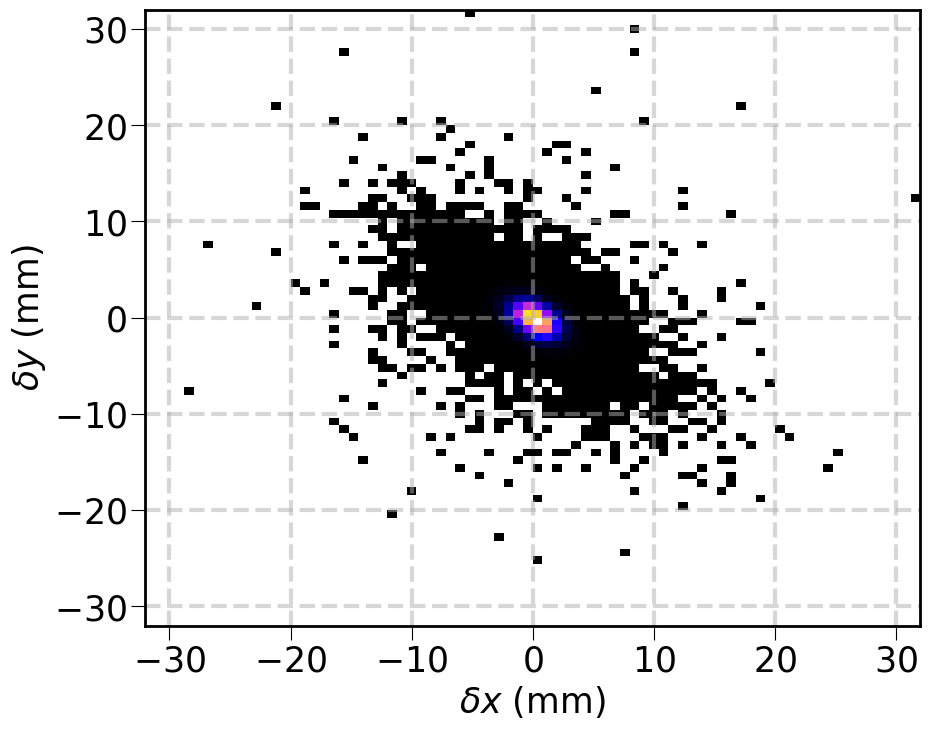

In [23]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

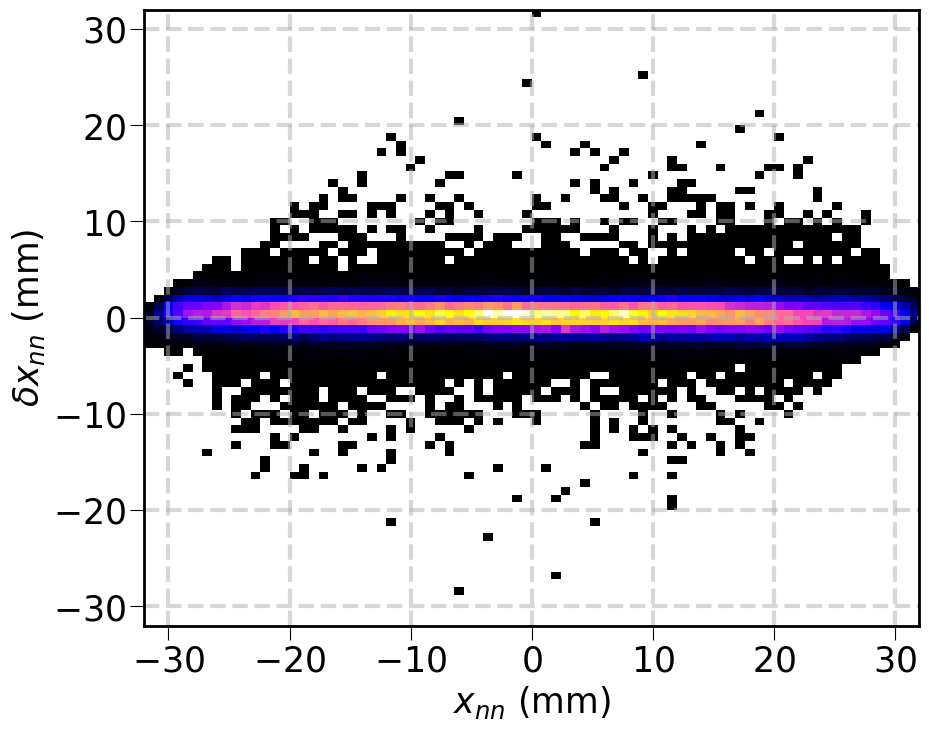

In [24]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_{nn}$ (mm)")
plt.ylabel("$\delta x_{nn}$ (mm)")
plt.grid()

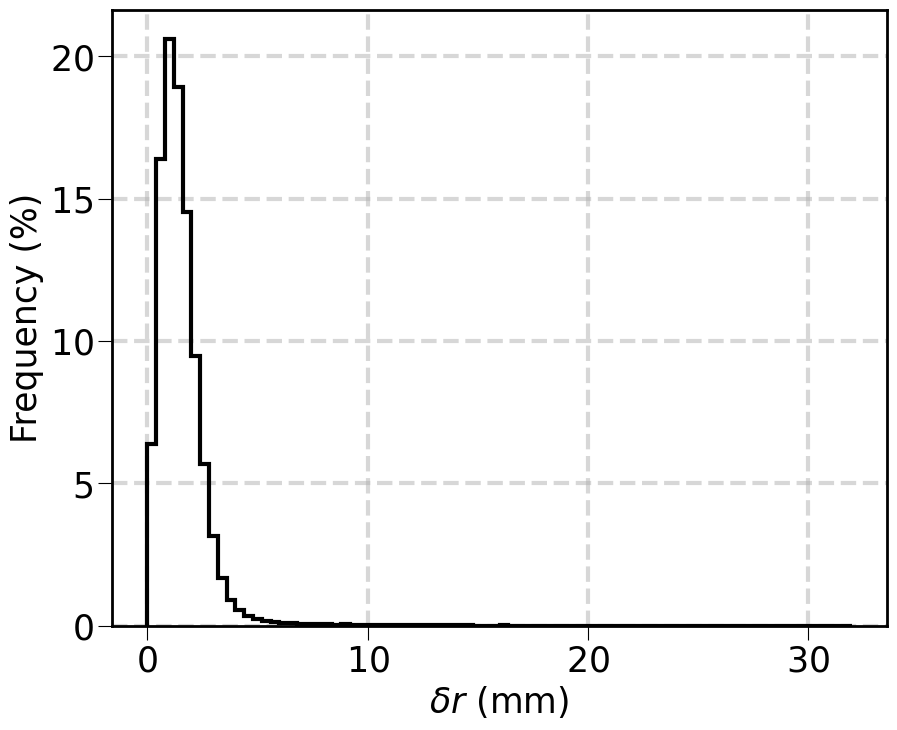

In [25]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

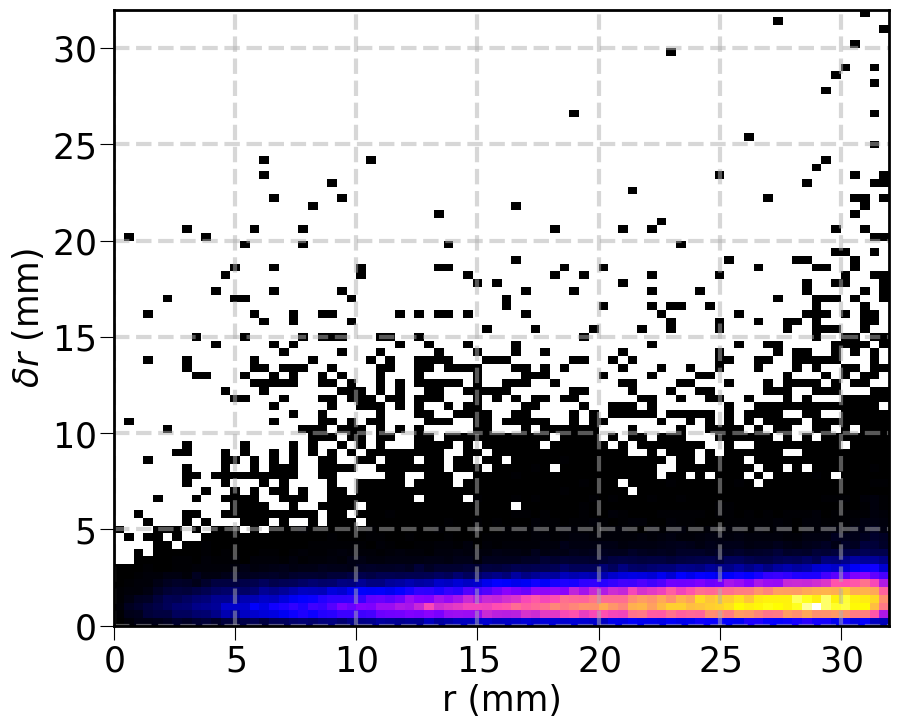

In [26]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

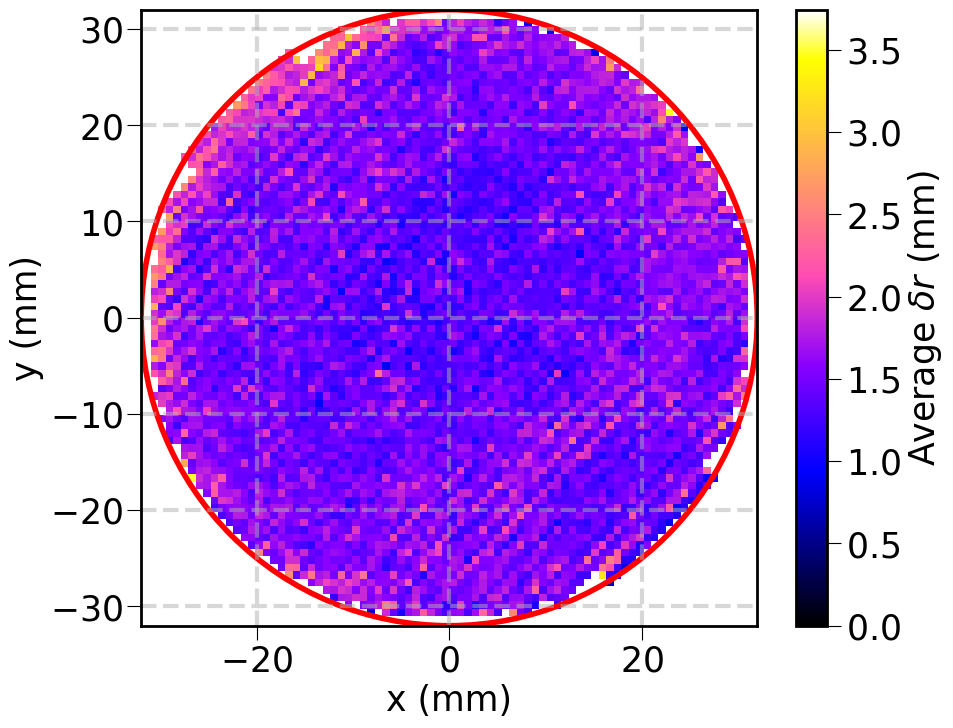

In [27]:
evts = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
errs = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
plt.imshow(errs.T, origin="lower", vmin=0, vmax=2.5*np.median(errs[errs>0]), extent=extents)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("Average $\delta r$ (mm)")
draw_el(plt.gca(), rmax)
plt.grid()

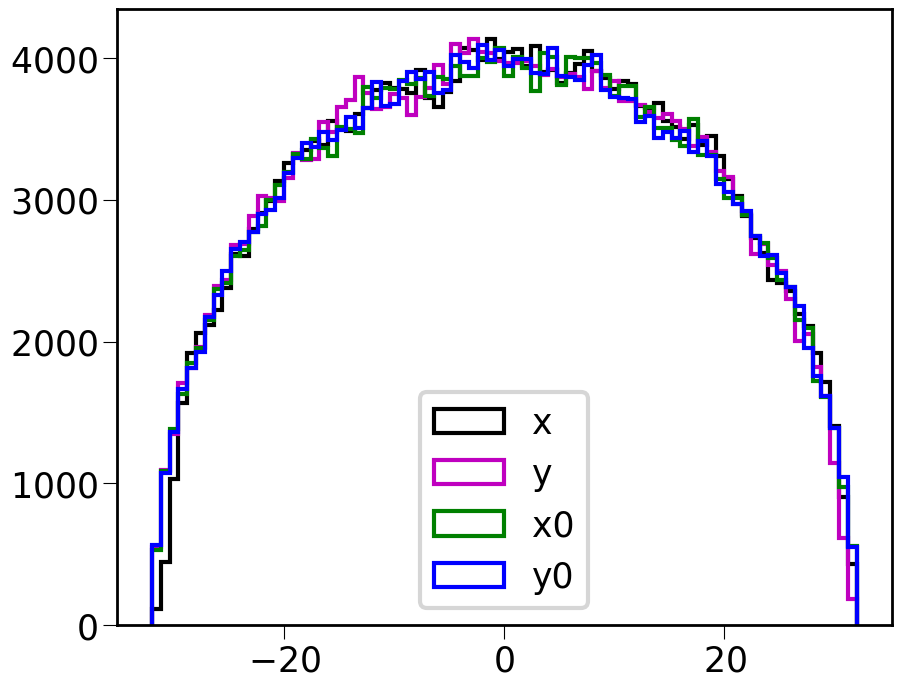

In [28]:
plt.hist(reco_nn.x , xybins, histtype="step", label="x");
plt.hist(reco_nn.y , xybins, histtype="step", label="y");
plt.hist(reco_nn.x0, xybins, histtype="step", label="x0");
plt.hist(reco_nn.y0, xybins, histtype="step", label="y0");
plt.legend()

In [29]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
event,,,,,,,,
0,7.804216,-7.343330,10.715889,8.271010,-6.295292,0.466794,1.048038,1.147293
1,22.911552,0.310028,22.913650,22.779494,1.884948,-0.132058,1.574920,1.580446
2,-7.014219,8.148063,10.751288,-6.758054,8.286354,0.256165,0.138291,0.291109
3,-0.045219,7.740740,7.740872,1.597290,6.897891,1.642509,-0.842849,1.846140
4,-5.529467,3.860798,6.743943,-5.959615,4.655453,-0.430148,0.794655,0.903606
...,...,...,...,...,...,...,...,...
49995,28.552930,-12.533412,31.182627,28.447715,-11.653506,-0.105215,0.879906,0.886174
49996,-7.002381,-27.783369,28.652206,-7.501487,-28.539692,-0.499106,-0.756323,0.906163
49997,5.919254,25.686257,26.359464,5.789411,25.822447,-0.129843,0.136190,0.188167


In [30]:
output = filenames[0].parent
output = output.parent / (output.stem + "_reco_summary.h5")
reco_nn.to_hdf(output, key="/data", complib="zlib", complevel=4, mode="w")

In [31]:
import datetime
print(f"Last execution: {datetime.datetime.now()}")

Last execution: 2026-03-03 14:22:39.311992
